# 🌊 Data Visualization Part 5: Seaborn Statistical & Categorical Masterclass
**From Categorical Scatter Plots to Regression, FacetGrids, and Pairplots**

Welcome to Part 5! Matplotlib is great for drawing shapes, but **Seaborn** is built for **statistical exploration**. In this notebook, we will master how to visualize categorical data, fit regression lines, calculate confidence intervals, and build multi-dimensional grid dashboards.

Every concept follows our **Mastery Framework**:

`Theory → Mental Model → Diagram → Code → Mistakes → Interview → Practice (Levels 1-5)`


In [1]:
# ==========================================
# 🛠️ SETUP & DATASETS
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print(f"Seaborn Version: {sns.__version__}")

# 1. Tips Dataset (Categorical & Numerical)
tips = sns.load_dataset('tips')

# 2. Penguins Dataset (Multivariate)
penguins = sns.load_dataset('penguins').dropna()

# 3. Diamonds Dataset (Large dataset for regression)
diamonds = sns.load_dataset('diamonds').sample(1000, random_state=42)

print("✅ Seaborn Datasets Loaded Successfully!")

Seaborn Version: 0.13.2
✅ Seaborn Datasets Loaded Successfully!


# 📘 Module 1: Categorical Scatter Plots (Strip & Swarm)

## 🧠 1. Theory & Mental Model
When visualizing how a numerical value varies across discrete categorical groups, standard scatter plots fail because points overlap along the categorical axes. Categorical scatter plots spread these points out to show row densities.
- **`stripplot()`**: Adds a random displacement factor (`jitter`) along the categorical axis to reveal point density.
- **`swarmplot()`**: Uses a specialized tree positioning algorithm to ensure zero points overlap, forming a swarm shape that directly reflects data density (like a beeswarm).
## 📊 2. Visual Diagram
```text
Stripplot (with jitter)      Swarmplot (Exact positioning)
Value ↑                      Value ↑
  |  . .  .   .                |    .  .
  | .   .  . .                 |   . . . .
  |.  .  .   .                 |  . . . .
  +----------------→           +----------------→
   CatA  CatB                   CatA  CatB
```

**🧠 Mental Model**: Think of a `stripplot` as a crowd of people standing randomly in lanes. A `swarmplot` is that same crowd organized into a structured marching band formation where every individual stands a clear distance apart.

## 💻 3. Code Example


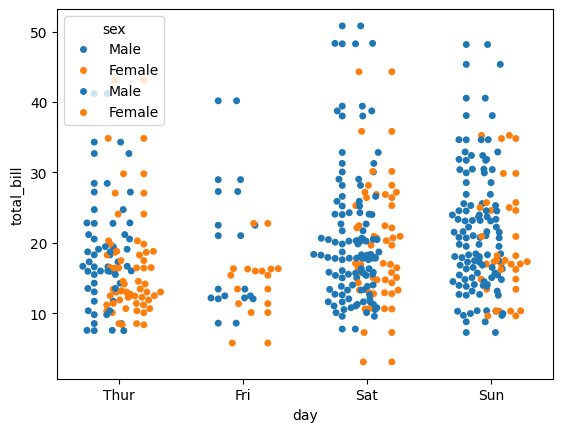

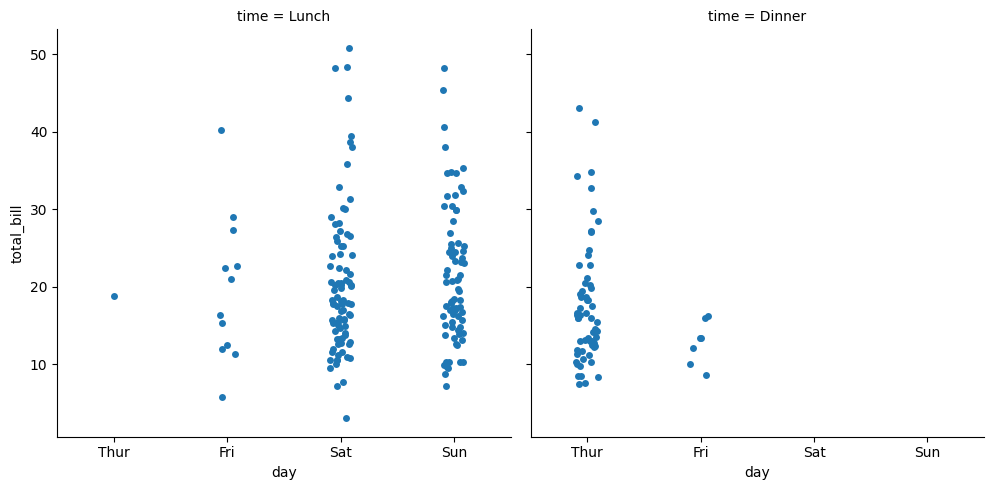

In [2]:
# Axes-Level: Stripplot
sns.stripplot(data=tips, x='day', y='total_bill', jitter=True, hue='sex')

# Axes-Level: Swarmplot
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex', dodge=True)

# Figure-Level: catplot (Allows Faceting!)
sns.catplot(data=tips, x='day', y='total_bill', kind='strip', col='time')


## ⚠️ 4. Common Mistakes
Using `swarmplot` on massive datasets (e.g., 100,000 rows). It will freeze your kernel because calculating exact non-overlapping positions is computationally expensive. Use `stripplot` or `boxplot` for large data.

## 🎤 5. Interview Question
**Q: What is the difference between `stripplot` and `swarmplot`?**
> **A:** `stripplot` adds random horizontal noise (`jitter`) to prevent overplotting, meaning the exact X-position is meaningless. `swarmplot` algorithmically adjusts points to prevent overlap, preserving the exact density and distribution shape.

**Q: How does `catplot()` relate to axis-level tools like `stripplot()`?**
> **A:** `catplot()` is a figure-level function. By altering the `kind parameter` (e.g., `kind='strip'` or `kind='swarm'`), it calls the respective axis-level function internally while managing its own `FacetGrid` for automated subplot handling.

## 🎯 6. Practice Tasks
*   **Level 1 (Easy):** Plot a `stripplot` on the tips dataset with `x='day'` and `y='total_bill'`. Turn off the point scattering by passing `jitter=False` to observe overlapping labels.
*   **Level 2 (Medium):** Add `hue='sex'` and `dodge=True` to separate the categories.
*   **Level 3 (Hard):** Use `sns.catplot()` with `kind='swarm'` and `col='smoker'` to facet the data.
*   **Level 4 (Expert):** Overlay a `boxplot` under a `swarmplot` to show both the summary statistics and the raw data points.
*   **Level 5 (Challenge):** Write a function that automatically chooses between `stripplot` and `swarmplot` based on the length of the DataFrame.



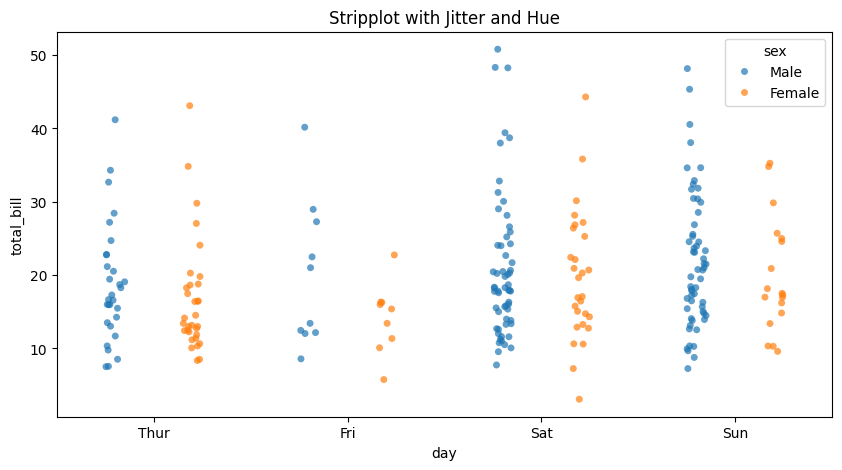

In [3]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 1
# ==========================================
# Example Execution
plt.figure(figsize=(10, 5))
sns.stripplot(data=tips, x='day', y='total_bill', jitter=True, hue='sex', dodge=True, alpha=0.7)
plt.title("Stripplot with Jitter and Hue")
plt.show()

# --- YOUR TURN ---
# Level 1-5: Build your categorical scatter plots!


# 📘 Module 2: Categorical Distribution (`boxplot` vs `violinplot`)

## 🧠 1. Theory & Mental Model
As datasets grow, individual point mapping becomes impossible. We need charts that compress raw records into statistical summary profiles.
- **`boxplot`**: Shows the 5-number summary (Min, Q1, Median, Q3, Max) and outliers. **Mental Model:** A statistical X-ray.
- **`violinplot`**: Combines a standard `boxplot` with a smoothed **Kernel Density Estimation (KDE)** curve on both sides. This captures bimodal distributions or hidden density shapes that a `boxplot` might flatten out. **Mental Model:** An X-ray wrapped in a 3D density cloud, showing the exact contours of where the data flows most heavily. Shows *multi-modal* distributions (multiple peaks).

## 📊 2. Visual Diagram (Boxplot Anatomy)
```text
      Max (Whisker)
         |
      ---|---  <- Q3 (75th percentile)
         |
      ---|---  <- Median (50th percentile)
         |
      ---|---  <- Q1 (25th percentile)
         |
      Min (Whisker)
       (*)      <- Outliers
```

## 💻 3. Code Example


<Axes: xlabel='day', ylabel='total_bill'>

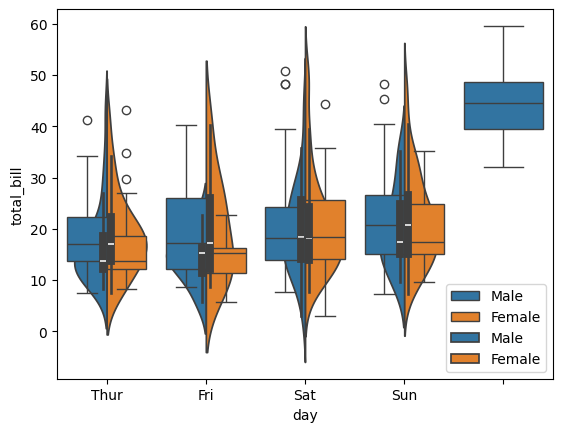

In [4]:
# Boxplot
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex')

# Violinplot (Split to compare distributions side-by-side)
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex', split=True)

# Single Boxplot (Univariate Numerical)
sns.boxplot(data=penguins, y='bill_length_mm')


## 🎤 4. Interview Question
**Q:** When should you use a Violinplot instead of a Boxplot?
**A:** Use a Violinplot when you suspect the data has a **multi-modal distribution** (e.g., bimodal). A boxplot will only show the median and hide the fact that there are two distinct peaks in the data.

## 🎯 5. Practice Tasks
*   **Level 1:** Create a `boxplot` of `total_bill` by `day`.
*   **Level 2:** Create a `violinplot` with `split=True` and `hue='sex'`.
*   **Level 3:** Use `catplot(kind='box')` to facet by `time`.
*   **Level 4:** Create a single boxplot for the `bill_length_mm` of the `penguins` dataset.
*   **Level 5:** Overlay a `boxplot` inside a `violinplot` (Hint: draw the violin first, then the box on top with a narrower `width`).


1. **Task 1 (Easy)**: Generate a horizontal `boxplot` analyzing the single numerical column `tips['total_bill']`. Identify the median value and look for outliers past the whiskers.
2. **Task 2 (Medium)**: Create a vertical `violinplot` on the `titanic` dataset comparing passenger class (`x='class'`) against their age (`y='age'`). Color differentiate by their survival status (`hue='alive'`).
3. **Task 3 (Hard)**: Optimize the violin plot from Task 2: use the `split=True` parameter to draw the survival profiles on opposite halves of the same violin structure, and set `inner='quart'` to draw internal quartile lines.

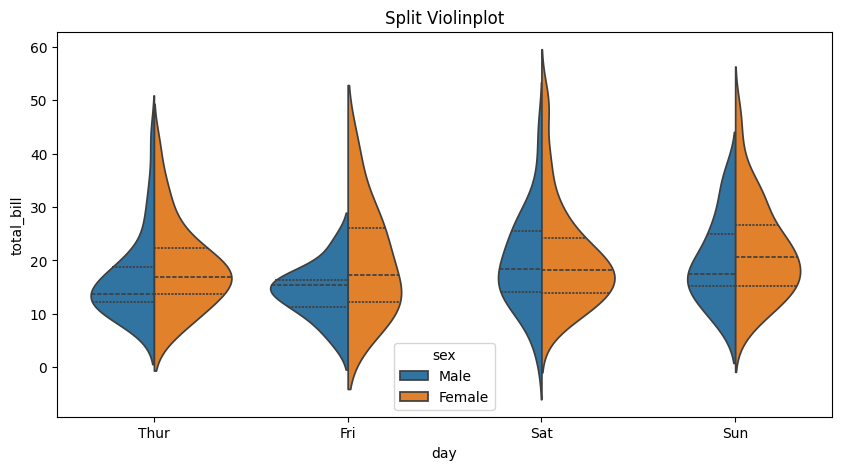

In [5]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 2
# ==========================================
# Example Execution
plt.figure(figsize=(10, 5))
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex', split=True, inner='quartile')
plt.title("Split Violinplot")
plt.show()

# --- YOUR TURN ---
# Level 1-5: Master the Box and Violin!


# 📘 Module 3: Categorical Estimates Plots (Bar, Point, Count)

## 🧠 1. Theory & Mental Model
These plots don't show raw data; they show **aggregated estimates** (usually the Mean) and their **Confidence Intervals** (error bars).
- **`barplot`**: Draws bars representing the mean value. Crucially, it automatically calculates a **Confidence Interval** (CI) using a statistical technique called **bootstrapping**, which it displays as an error bar on top of the bar.
- **`pointplot`**: Instead of bars, it places a point marker at the mean value and connects them across categories with lines. This is excellent for tracking changes or relative trends across category groupings (great for seeing *trends* or *interactions*).
- **`countplot`**: A histogram for categorical data. It just counts the number of observations (no Y-variable needed). 

## ⚠️ 2. The `errorbar` Update (Common Mistake)
In older Seaborn versions, we used `ci=95`. In Seaborn 0.12+, `ci` is deprecated! You must now use `errorbar=('ci', 95)` or `errorbar=('sd', 1)`.

## 💻 3. Code Example


<Axes: xlabel='day', ylabel='total_bill'>

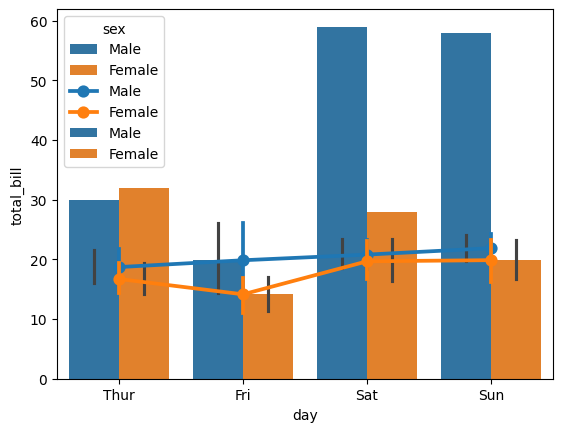

In [6]:
# Barplot (Mean + 95% CI)
sns.barplot(data=tips, x='day', y='total_bill', hue='sex', errorbar=('ci', 95))

# Pointplot (Connecting the means)
sns.pointplot(data=tips, x='day', y='total_bill', hue='sex')

# Countplot (Just counting categories)
sns.countplot(data=tips, x='day', hue='sex')


## 🎤 4. Interview Question
**Q: What is the difference between `barplot` and `countplot`?**
> **A:** `barplot` requires a numerical Y-variable and aggregates it (e.g., Mean of `total_bill`). `countplot` only takes a categorical X-variable and simply counts the *frequency* of occurrences (like a categorical histogram).
**Q: What does that black line on top of a Seaborn barplot represent, and how is it calculated?**
> **A:** It represents an Error Bar or **Confidence Interval (CI)** (typically a 95% CI). Seaborn uses a computationally intensive method called **bootstrapping** (re-sampling the data with replacement thousands of times) to estimate the uncertainty of the mean. If the error bar is narrow, the mean estimate is highly stable.

## 🎯 5. Practice Tasks
*   **Level 1:** Create a `barplot` of `tip` by `day`.
*   **Level 2:** Change the error bar to show Standard Deviation instead of Confidence Interval (`errorbar=('sd', 1)`).
*   **Level 3:** Create a `pointplot` of `total_bill` by `size`.
*   **Level 4:** Create a `countplot` of `smoker` vs `time`.
*   **Level 5:** Use `catplot(kind='count')` to facet the count of `day` by `sex`.


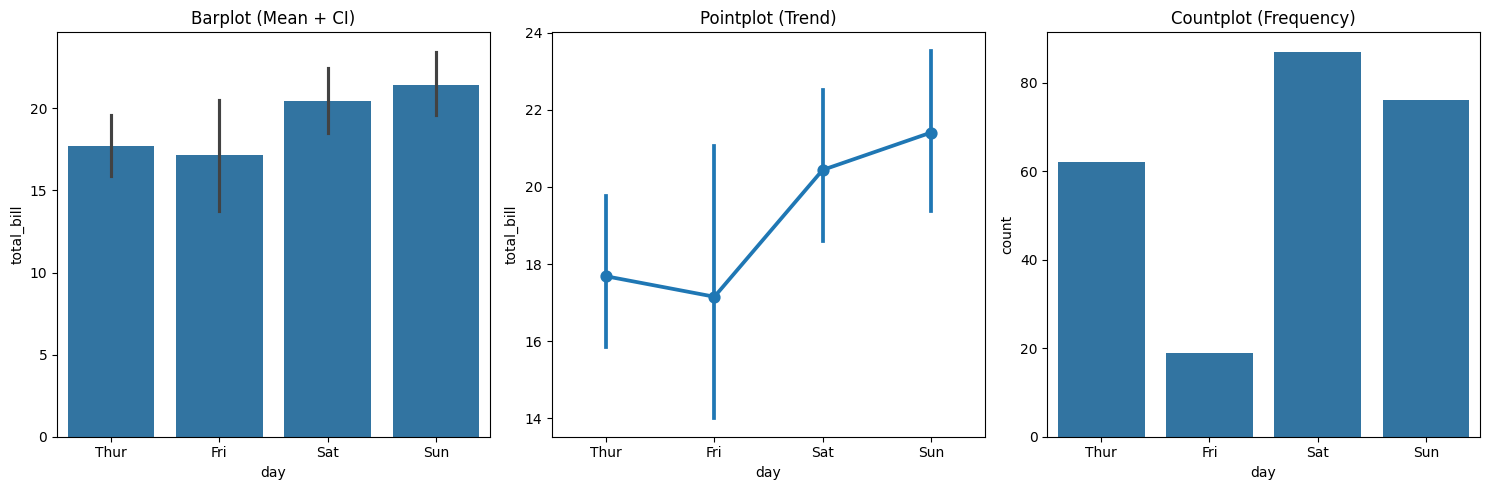

In [9]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 3
# ==========================================
# Example Execution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.barplot(data=tips, x='day', y='total_bill', ax=axes[0], errorbar=('ci', 95))
axes[0].set_title("Barplot (Mean + CI)")

sns.pointplot(data=tips, x='day', y='total_bill', ax=axes[1])
axes[1].set_title("Pointplot (Trend)")

sns.countplot(data=tips, x='day', ax=axes[2])
axes[2].set_title("Countplot (Frequency)")

plt.tight_layout()
plt.show()

# --- YOUR TURN ---
# Level 1-5: Master the Estimates!


# 📘 Module 4: Regression Plots & FacetGrid 

## 🧠 1. Theory & Mental Model
Regression plots evaluate relationships between numerical variables to establish linear trends. Seaborn can automatically fit an OLS (Ordinary Least Squares) regression line and plot a 95% confidence band around it.
- **`regplot`**: An axis-level function that draws a scatter plot and fits a linear regression line ($y = mx + c$) along with a shaded 95% confidence interval for that regression. Plots scatter + regression line. (Does not support `col`/`row` faceting).
- **`lmplot`**: A figure-level function that packages `regplot` inside a **FacetGrid**, to split the data into multiple subplots based on categories.
- **`residplot`**: A diagnostic tool that plots the `residuals` (the error gap between the actual data points and the regression line). Used to check if the linear assumption is valid (residuals should be randomly scattered around 0).

## 📊 2. Visual Diagram (FacetGrid)
```text
lmplot(data, x='bill', y='tip', col='time')
+-------------------+-------------------+
|   Lunch Scatter   |   Dinner Scatter  |
|   + Reg Line      |   + Reg Line      |
+-------------------+-------------------+
```
**⚠️ Common Mistake (The Linear Fit Assumption)**: Assuming a straight line fits your data well just because `regplot` drew it. Always run a `residplot()`. If the dots are distributed randomly around the center line, your linear model is valid. If the dots form a curve or pattern, your data has a non-linear relationship and a linear fit is structurally biased.

## 💻 3. Code Example


<Axes: xlabel='total_bill', ylabel='tip'>

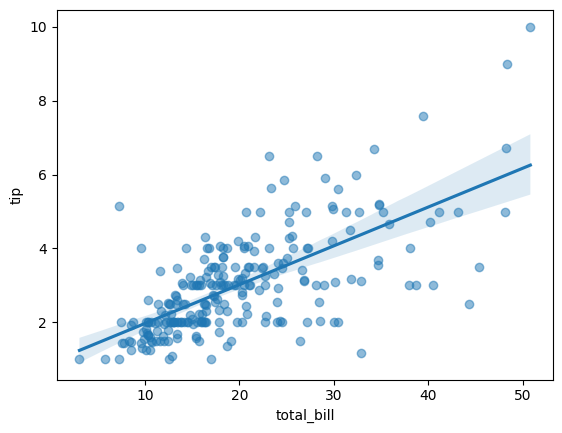

In [11]:
# Axes-Level
sns.regplot(data=tips, x='total_bill', y='tip', scatter_kws={'alpha':0.5})

<Axes: title={'center': 'time = Dinner'}, xlabel='total_bill', ylabel='tip'>

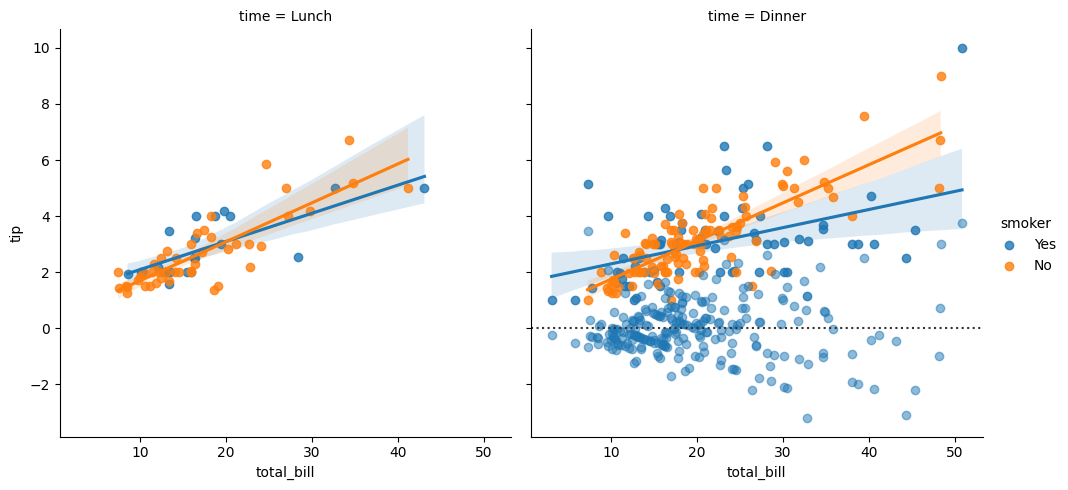

In [14]:
# Figure-Level (Faceting)
sns.lmplot(data=tips, x='total_bill', y='tip', col='time', hue='smoker')

# Residual Plot
sns.residplot(data=tips, x='total_bill', y='tip', scatter_kws={'alpha':0.5})


## 🎤 4. Interview Question
**Q:** What is the difference between `regplot` and `lmplot`?**
> **A:** `regplot` is an **axes-level** function that draws on a single Matplotlib Axes. `lmplot` is a **figure-level** function that combines `regplot` with a `FacetGrid`, allowing you to split the regression lines across multiple subplots using `col` or `row`.

## 🎯 5. Practice Tasks
*   **Level 1:** Create a `regplot` of `total_bill` vs `tip`.
*   **Level 2:** Use `lmplot` to facet the regression by `day` (`col='day', col_wrap=2`).
*   **Level 3:** Create a `residplot` and explain what it tells you about the relationship between bill and tip.
*   **Level 4:** Use `lmplot` with `hue='smoker'` and `col='time'`.
*   **Level 5:** Fit a polynomial regression (order=2) using `regplot` with `order=2`.


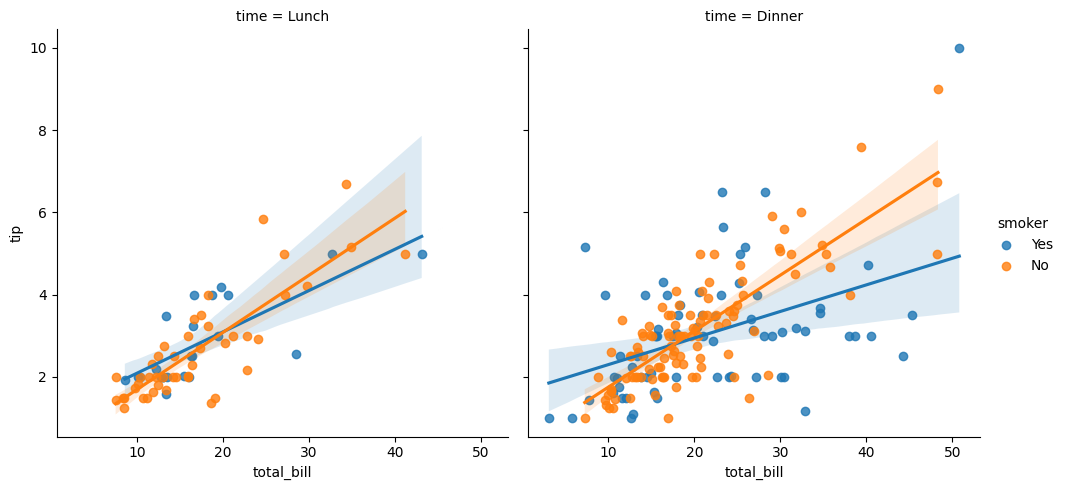

In [15]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 4
# ==========================================
# Example Execution
sns.lmplot(data=tips, x='total_bill', y='tip', col='time', hue='smoker', height=5, aspect=1)
plt.show()

# --- YOUR TURN ---
# Level 1-5: Master Regression and FacetGrids!


# 📘 Module 5: Statistical Multi-Plot Grids (Pairwise & Joint Distributions) (`pairplot` vs `PairGrid`, `jointplot` vs `JointGrid`)

## 🧠 1. The Grid vs Plot Dichotomy:
When starting exploratory data analysis, you often need to look at interactions across all variables at the same time. These grid architectures automate this process.
- **`jointplot`**: Focuses on **two** variables. Shows a central scatter/heatmap, and marginal distributions (histograms/KDEs) on the top and right edges.
- **`pairplot`**: The ultimate EDA tool. Takes an entire DataFrame and plots a **matrix** of all pairwise relationships. Diagonal shows univariate distributions (KDE/Hist).

## 📊 2. Visual Diagram (Pairplot Matrix)
```text
        | Var 1 | Var 2 | Var 3 |
---------------------------------
Var 1   | Hist  | Scat  | Scat  |
Var 2   | Scat  | Hist  | Scat  |
Var 3   | Scat  | Scat  | Hist  |
```

## 💻 3. Code Example


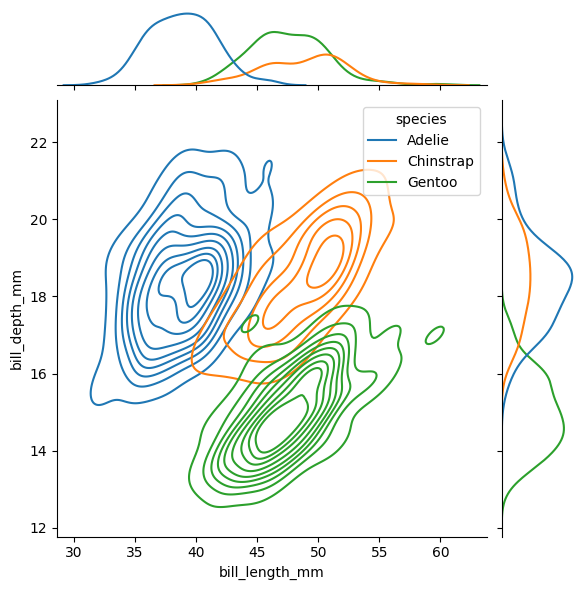

In [17]:
# Jointplot (2 Variables + Marginals)
sns.jointplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species', kind='kde')

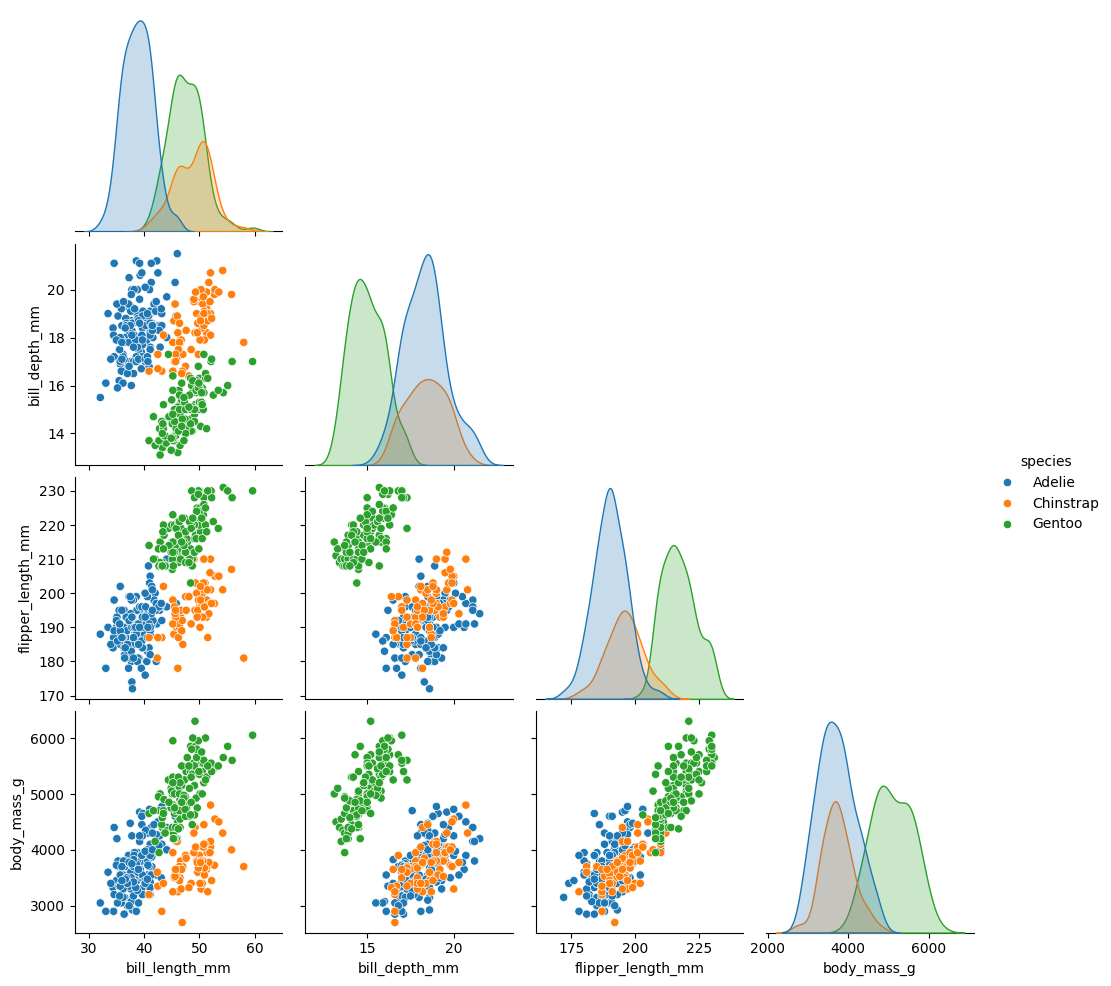

In [18]:
# Pairplot (All Variables)
sns.pairplot(data=penguins, hue='species', corner=True) # corner=True saves space!


## 💡 4. Fun Fact
Under the hood, `jointplot` uses a **`JointGrid`**, and `pairplot` uses a **`PairGrid`**. Just like `lmplot` uses `FacetGrid`. If you need extreme, granular customization of the subplots, you can instantiate the `Grid` object manually and map custom functions to it!

## 🎯 5. Practice Tasks
*   **Level 1:** Create a `jointplot` of `total_bill` and `tip` using `kind='reg'`.
*   **Level 2:** Create a `jointplot` using `kind='hex'` for a large dataset (like `diamonds`).
*   **Level 3:** Create a `pairplot` of the `penguins` dataset, colored by `species`.
*   **Level 4:** Use `corner=True` in `pairplot` to hide the redundant upper triangle.
*   **Level 5:** Use `PairGrid` manually to map `scatterplot` to the lower triangle and `kdeplot` to the upper triangle.

1. Generate an automated matrix of all numeric relationships in the iris dataset using the shortcut function sns.pairplot(), color-coding by hue='species'.
2. Map a sns.jointplot() for total_bill (X) and tip (Y) from the tips dataset. Set kind='hex' to convert the distribution into hexagonal density bins.
3. Advanced Constructor Challenge: Instantiated an empty grid layout using grid = sns.JointGrid(data=tips, x='total_bill', y='tip'). Map a scatter plot to the central region using grid.plot_joint(plt.scatter) and a kernel density curve to the margins using grid.plot_marginals(sns.kdeplot).

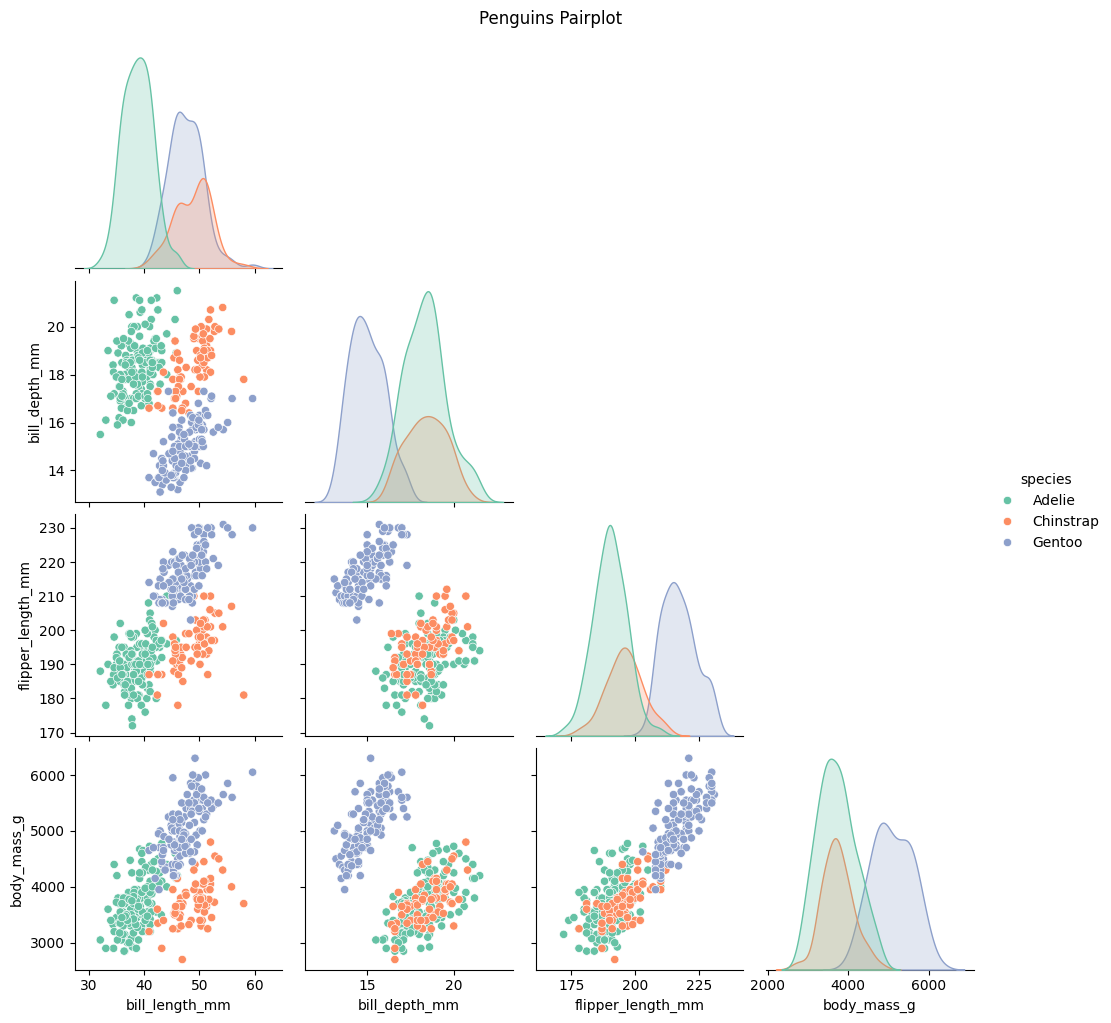

In [19]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 5
# ==========================================
# Example Execution
sns.pairplot(data=penguins, hue='species', corner=True, palette='Set2')
plt.suptitle("Penguins Pairplot", y=1.02)
plt.show()

# --- YOUR TURN ---
# Level 1-5: Master Pairwise and Joint plots!


# 📘 Module 6: Utility Functions & Summary

## 🧠 1. Utility Functions: `load_dataset`
Seaborn comes with a built-in library of classic datasets (like `tips`, `penguins`, `titanic`, `diamonds`). 
```python
df = sns.load_dataset('penguins')
```
**Why use it?** It instantly downloads the CSV from the Seaborn GitHub repo and returns a clean Pandas DataFrame. Perfect for practicing without hunting for data!

## 📊 2. The Seaborn Hierarchy Cheat Sheet
```text
Axes-Level (Draws on ONE plot)      Figure-Level (Draws a GRID of plots)
-------------------------------------------------------------------------
scatterplot         →               relplot (kind='scatter')
lineplot            →               relplot (kind='line')
histplot / kdeplot  →               displot
boxplot / violinplot→               catplot (kind='box' / 'violin')
barplot / countplot →               catplot (kind='bar' / 'count')
regplot             →               lmplot
```

## 🎤 3. Interview Question
**Q:** Why does Seaborn have both Axes-level and Figure-level functions?
**A:** Axes-level functions (like `scatterplot`) are designed to be easily integrated into complex Matplotlib dashboards (using `plt.subplots()`). Figure-level functions (like `relplot`) manage their own figure and are specifically designed for rapid **Faceting** (splitting data by categories into grids).


In [20]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 6
# ==========================================
# Example Execution
print("Available Seaborn Datasets:")
# sns.get_dataset_names() # Uncomment to see all 30+ datasets!

# Load a new dataset
titanic = sns.load_dataset('titanic')
print(titanic.head())

# --- YOUR TURN ---
# Task: Load the 'titanic' dataset. 
# Create a catplot showing the survival rate (mean of 'survived') by 'class' and 'sex'.


Available Seaborn Datasets:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# 🎉 Congratulations!
You have mastered **Data Visualization Part 5: Seaborn Statistical & Categorical Masterclass**.
You now know how to:
✅ Visualize categorical data using Strip, Swarm, Box, and Violin plots.
✅ Calculate and plot statistical estimates with Confidence Intervals.
✅ Fit regression lines and analyze residuals.
✅ Build multi-dimensional dashboards using FacetGrids (`lmplot`, `catplot`).
✅ Explore entire datasets instantly using `pairplot` and `jointplot`.

### 🚀 Next Steps
You are now ready for **Data Visualization Part 6: Interactive Plotly** – taking your static Seaborn plots and making them interactive for the web!


# 🗺️ Mastering Seaborn Multi-Plot Grids: High-Level Shortcuts vs. Object-Oriented Constructors

Welcome to the ultimate deep-dive notebook on Seaborn's multi-plot layout engines. When analyzing complex datasets, single charts often fail to show the whole story. We frequently need to see a plot alongside its separate data summaries, or examine a grid showing how multiple features interact with each other.

Seaborn handles this using two distinct approaches:

1. **Shortcut Functions (`jointplot`, `pairplot`)**: Instant, high-level commands that assume the layout and default charts for you.
2. **Object-Oriented Constructors (`JointGrid`, `PairGrid`)**: Empty grid canvases that give you absolute control to design what goes into every section of the plot grid.

Run the setup cell below to load our standard datasets before we begin.

---

**[Code Cell]**

```python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set professional global layout baseline
sns.set_theme(style="whitegrid")

# Load standard datasets for advanced exploratory analysis
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')

print("✅ Advanced Multi-Plot Environments Initialized!")

```

---

**[Markdown Cell]**

## 1. `sns.jointplot()` — The Bivariate Shortcut

**Theory:** `sns.jointplot()` is a high-level shortcut function designed to analyze exactly **two** numerical variables. It displays a central bivariate plot (showing how the two variables interact) surrounded by two independent univariate **marginal plots** on the top and right edges (showing the standalone distribution of each variable).

**🧠 Mental Model:** Imagine looking at a 2D map tracking where darts landed on a target (the central scatter plot), with two independent line charts running along the top and right edges of the target board showing the total density of hits along the latitude and longitude lines.

**📊 Visual Diagram:**

```text
                  ┌──────────────────┐
                  │ Top Margin (X)   │
                  └──────────────────┘
┌──────────────┐  ┌──────────────────┐
│              │  │                  │
│ Right Margin │  │   Central Joint  │
│ (Y)          │  │   Plot (X vs Y)  │
│              │  │                  │
└──────────────┘  └──────────────────┘

```

**⚠️ Common Mistake:** Trying to modify the size of a `jointplot()` using Matplotlib's standard `plt.figure(figsize)`. Because `jointplot` is a figure-level function under the hood, it creates its own canvas window. You must change its size using the explicit `height` parameter directly inside the function call.

**🎤 Interview Question:** *When would you change the `kind` parameter in `jointplot` from `'scatter'` to `'hex'` or `'kde'`?*
**Answer:** When your dataset contains a high density of points (overplotting). In large datasets, thousands of scattered dots overlap into an unreadable solid blob. Changing `kind='hex'` groups points into hexagonal bins, and `kind='kde'` fits a smooth contour layout, making density patterns immediately visible.

### 🎯 Practice Tasks

* **Task 1.1 (Easy):** Create a basic `sns.jointplot()` comparing `total_bill` (X) vs `tip` (Y) from the `tips` dataset.
* **Task 1.2 (Medium):** Change the layout type of the joint plot to use hexagonal bins by passing `kind='hex'`.
* **Task 2.3 (Hard):** Build a joint plot using `kind='reg'` (adds a linear regression line) and separate the categories visually by passing `hue='time'`. Observe how the marginal charts adapt to show separate density curves for lunch and dinner.

---

**[Code Cell]**

```python
# --- EXAMPLE CODE ---
# Simple jointplot with default scatter and marginal histograms
sns.jointplot(data=tips, x="total_bill", y="tip", height=6)
plt.show()

# --- PRACTICE AREA ---
# Task 1.1: Basic total_bill vs tip jointplot


# Task 1.2: Total_bill vs tip using kind='hex'


# Task 1.3: Total_bill vs tip using kind='reg' and hue='time'


```

---

**[Markdown Cell]**

## 2. `sns.JointGrid` — The Object-Oriented Blueprint

**Theory:** `sns.JointGrid` is the underlying object-oriented constructor that powers `jointplot`. Instead of assuming what charts you want, it instantiates an empty layout with three empty frames: a central grid space, a top margin banner, and a right margin banner. You then programmatically map any chart type you want to these spaces.

**🧠 Mental Model:** An architect hands you a blueprint for a picture frame consisting of one large square in the middle and two narrow banners on the edges. You have total creative freedom to paint an advanced scatter plot in the center, a KDE curve on the top banner, and a rug plot on the right banner.

**🛠️ Core Syntax Construction:**

```python
grid = sns.JointGrid(data=df, x='col1', y='col2')
grid.plot_joint(sns.scatterplot)      # Defines the central plot weapon
grid.plot_marginals(sns.kdeplot)      # Defines the marginal plot weapon

```

### 🎯 Practice Tasks

* **Task 2.1 (Easy):** Instantiate an empty `sns.JointGrid` passing `data=tips`, `x='total_bill'`, and `y='tip'`. Run the cell to observe the empty canvas layout.
* **Task 2.2 (Medium):** Take your empty grid from Task 2.1 and map a standard `plt.scatter` to the central region using `.plot_joint()`, and a `sns.histplot` to the margins using `.plot_marginals()`.
* **Task 2.3 (Hard):** Build an asymmetrical structural masterpiece: Map a kernel density estimation plot (`sns.kdeplot`) to the center joint space. Then, map a `sns.histplot` strictly to the top margin, and an independent `sns.rugplot` strictly to the right margin using the individual components `grid.ax_marg_x` and `grid.ax_marg_y`.

---

**[Code Cell]**

```python
# --- EXAMPLE CODE ---
# Initializing a custom blueprint grid
grid = sns.JointGrid(data=tips, x="total_bill", y="tip")

# Mapping completely different libraries and styles to the central vs. marginal components
grid.plot_joint(sns.scatterplot, color="purple", alpha=0.6, marker="s")
grid.plot_marginals(sns.histplot, color="teal", kde=True, alpha=0.3)
plt.show()

# --- PRACTICE AREA ---
# Task 2.1: Initialize an empty JointGrid blueprint


# Task 2.2: Map a central plt.scatter and marginal sns.histplot to the grid


# Task 2.3: Advanced asymmetric mapping - central kdeplot, top margin histplot, right margin rugplot


```

---

**[Markdown Cell]**

## 3. `sns.pairplot()` — The Exploratory Matrix Shortcut

**Theory:** `sns.pairplot()` is a high-level shortcut function designed for **Multivariate Exploratory Data Analysis (EDA)**. Instead of focusing on two variables, it evaluates your **entire DataFrame**, identifies every single numeric column, and constructs a massive symmetric matrix matching every numerical column against every other numerical column.

**🧠 Mental Model:** Think of `pairplot` as a multiplication table. If your DataFrame has 4 numeric columns, it builds a 4x4 grid of charts where the row labels and column headers are the column names. Where a column crosses itself on the diagonal line, it displays a simple univariate distribution chart (like a histogram or KDE) because a column cannot be mapped against itself as a scatter plot.

**📊 Visual Diagram:**

```text
          [ Column A ]       [ Column B ]
[Col A]   Univariate Hist    Scatter (A vs B)
[Col B]   Scatter (B vs A)   Univariate Hist

```

**⚠️ Common Mistake (The Memory Exploding Trap):** Passing a huge raw DataFrame with 40 numeric columns into `sns.pairplot()`. This forces Seaborn to calculate and render a matrix of $40 \times 40 = 1600$ individual subplots simultaneously. This will instantly freeze your Google Colab runtime environment. Always filter your DataFrame columns down to a core set of 3–5 variables before calling `pairplot`.

### 🎯 Practice Tasks

* **Task 3.1 (Easy):** Run an automated `sns.pairplot()` across the built-in `iris` dataset. Observe how it distinguishes relationships across the structural metrics.
* **Task 3.2 (Medium):** Apply categorical coloring to the matrix by passing `hue='species'`. Observe how this separates the different groups across every subplot in the grid.
* **Task 3.3 (Hard):** Fully customize the shortcut matrix execution: change the off-diagonal plots to fit linear regressions by passing `kind='reg'`, and force the central diagonal plots to render as stacked histograms by passing `diag_kind='hist'`.

---

**[Code Cell]**

```python
# --- EXAMPLE CODE ---
# Filter tips dataset down to essential numeric columns to save canvas memory
tips_subset = tips[['total_bill', 'tip', 'size']]

# Quick shortcut matrix with categorical classification
sns.pairplot(data=tips_subset, label="Tips Matrix")
plt.show()

# --- PRACTICE AREA ---
# Task 3.1: Automated pairplot on the iris dataset


# Task 3.2: Pairplot on the iris dataset with hue='species'


# Task 3.3: Pairplot with kind='reg' and diag_kind='hist' on the iris dataset


```

---

**[Markdown Cell]**

## 4. `sns.PairGrid` — The Object-Oriented Matrix Constructor

**Theory:** `sns.PairGrid` is the object-oriented constructor behind `pairplot`. It initializes a large, blank matrix grid mapped out by your DataFrame columns. It provides a unique analytical advantage: you can specify completely different chart architectures for the upper triangle, the lower triangle, and the central diagonal line of subplots.

**🧠 Mental Model:** Think of `PairGrid` as an asymmetrical tactical map. It allows you to look at the exact same variable relationship from two different visual perspectives: you can display a granular scatter plot on the upper triangle to check individual coordinate spreads, and a fluid contour density map (`kdeplot`) on the lower triangle to evaluate cluster volume.

**🛠️ Core Syntax Construction:**

```python
g = sns.PairGrid(df, hue='category')
g.map_upper(sns.scatterplot)    # Rules for the top-right triangle charts
g.map_lower(sns.kdeplot)        # Rules for the bottom-left triangle charts
g.map_diag(sns.histplot)        # Rules for the central corner-to-corner line

```

### 🎯 Practice Tasks

* **Task 4.1 (Easy):** Instantiate an empty `sns.PairGrid` on the `iris` dataset, tracking the `hue='species'` parameter. Run the cell to observe the empty structural matrix cells.
* **Task 4.2 (Medium):** Take your empty grid structure and use `.map_offdiag(plt.scatter)` to apply simple uniform scatter charts to every cell outside the center diagonal line, and `.map_diag(sns.histplot)` to map histograms down the center.
* **Task 4.3 (Hard):** Construct an asymmetrical data intelligence grid: map standard scatter plots (`sns.scatterplot`) to the upper triangle, detailed density contours (`sns.kdeplot`) with transparency (`alpha=0.5`) to the lower triangle, and clean non-stacked histograms (`sns.histplot`) down the central diagonal axis.

---

**[Code Cell]**

```python
# --- EXAMPLE CODE ---
# Building an advanced asymmetrical, multi-perspective matrix layout
g_example = sns.PairGrid(data=tips[['total_bill', 'tip', 'size']])

# Designing different visualization weapons for different regions of the matrix
g_example.map_upper(sns.scatterplot, color="teal", marker="o")
g_example.map_lower(sns.kdeplot, cmap="Blues_d", alpha=0.6)
g_example.map_diag(sns.histplot, color="orange", kde=True)
plt.show()

# --- PRACTICE AREA ---
# Task 4.1: Initialize an empty PairGrid on the iris dataset with hue='species'


# Task 4.2: Map off-diagonal scatter plots and diagonal histograms on your iris grid


# Task 4.3: Asymmetric construction challenge - upper scatterplot, lower kdeplot, diagonal histplot on the iris dataset


```